# Capítulo 1 — The role of probabilities in science

Exemplos 1.3.4 e 1.4.1 de Phil Gregory, *Bayesian Logical Data Analysis for the Physical Sciences*.

## Objetivos

- distinguir **prior, likelihood, evidência e posterior**;
- comparar hipóteses (qual é mais favorável) discretas por meio das odds e do fator de Bayes;
- visualizar o efeito da taxa-base em um teste diagnóstico;
- alterar as hipóteses do problema e interpretar o resultado.

In [1]:
# Imports necessários

import matplotlib.pyplot as plt
import numpy as np

# Melhorar figuras e configurações básicas para os plots

%config InlineBackend.figure_format = "retina"

plt.style.use("seaborn-v0_8-whitegrid") # Grid bonita
np.set_printoptions(precision=6, suppress = True) # Casas decimais

## Funções básicas que vamos utilizar 

Em ambas as questões precisaremos medir a evidência - $p(D\mid I)$ - e também utilizar o teorema de Bayes, que estabelece

$$p(H_i\mid D,I)=\frac{p(H_i\mid I)p(D\mid H_i,I)}{p(D\mid I)}$$

Temos: 
1. $p(H_i\mid D,I)$: Posteriori, probabilidade da teoria estabelecido dados como verdades.
2. $p(D\mid H_i,I)$: Likelyhood, probabilidade dos dados assumindo que a teoria é verdadade.
3. $p(H_i\mid I)$: Prior, probabilidade da sua teoria ser verdadeira assumindo um intervalo para os dados (prior)
4. $p(D\mid I)$: Evidencia, probabilidade dos dados -- Aqui temos informações que às vezes não aparecem na nossa posterior, nos informando sobre o quão provável é determinada teoria.

Nas questões podemos quebrar essas medições em 3 etapas diferentes, de modo que podemos estabelecer funções elementares que calculem:

$$
w_i=p(H_i\mid I)p(D\mid H_i,I),
$$

$$
p(D\mid I)=\sum_i w_i,
$$

$$
p(H_i\mid D,I)=\frac{w_i}{p(D\mid I)}.
$$

Uma função calcular $w_i$, likelyhood com prior, isso será essencial para calcularmos a evidência e a posterior, que precisa do fator de normalização (evidência).

Também é interessante montar funções auxiliares para cada um dos problemas.


In [2]:
def normalize(weights): # Função auxliar para ajudar na normalização e checagem
    "Normaliza um vetor"
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    return weights/total

def gaussian_pdf(x, mean, sigma): # Utilizada no problema 1.3.4 (representa p(D|H,I))
    "Densidade Gaussiana avaliada em x, com média mean e desvio sigma"
    x = np.asarray(x,dtype=float)
    mean = np.asarray(mean, dtype=float)
    z = (x-mean)/sigma

    return np.exp(-0.5 * z**2) / (np.sqrt(2.0*np.pi) * sigma)

def posterior_discrete(prior, likelihood): # Achar posteriores e evidencias - Vamos utilizar no 1.3.4
    "Calcula a posterior e a evidência para um conjunto discreto de hipóteses"
    prior = normalize(prior)
    likelihood = np.asarray(likelihood, dtype=float) # Não precisa ser normalizado pois é função dos dados!

    joint_weights = prior * likelihood # Equivalente ao w_i na parte acima

    evidence = joint_weights.sum() # Somando w_i (teorias) achamos a evidencia devido normalização

    posterior = joint_weights / evidence # Dividindo o vetor de w_i pela evidencia temos as posteriors

    return posterior, evidence
    

## Exemplo 1.3.4 — comparação entre dois modelos

Dois modelos fazem previsões para a distância de uma estrela: $d_1=100\,\mathrm{ly}$ e $d_2=200\,\mathrm{ly}$. A medida encontrada é $d=120\,\mathrm{ly}$ e o erro observacional é Gaussiano, com $\sigma=40\,\mathrm{ly}$. Inicialmente, os modelos têm probabilidades iguais, ou seja, $p(M_i\mid I)= 0.5$.

Para $i=1,2$,

$$
p(D\mid M_i,I)=\frac{1}{\sqrt{2\pi}\sigma}
\exp\left[-\frac{(d-d_i)^2}{2\sigma^2}\right].
$$

A comparação é feita pelas odds posteriores (razão das posteriores, que nesse caso é idêntico ao fator de bayes, que é a razão das likelihoods),

$$
O_{12}=\frac{p(M_1\mid D,I)}{p(M_2\mid D,I)}
=\frac{p(M_1\mid I)}{p(M_2\mid I)}
\frac{p(D\mid M_1,I)}{p(D\mid M_2,I)} =\frac{p(D\mid M_1,I)}{p(D\mid M_2,I)} .
$$

In [3]:
predictions = np.array([100.0, 200.0])  # previsões de M1 e M2 [ly]
measurement = 120.0                     # medida observada de fato
sigma = 40.0                            # Desvio da gaussiana: Igual para ambos os modelos, entra na likelihood
priors = np.array([0.5, 0.5])           # p(M1 | I) e p(M2 | I), as priors da teoria

# Passo 1: likelihood da medida sob cada modelo
likelihoods = gaussian_pdf(measurement, predictions, sigma)

# Passo 2: pesos conjuntos p(M_i | I) p(D | M_i, I)
joint_weights = priors * likelihoods

# Passos 3 e 4: evidência e posterior normalizada
posterior, evidence = posterior_discrete(priors, likelihoods)

# Comparação entre os modelos
prior_odds = priors[0] / priors[1] # Deve ser 1, não tem modelo favoricido pela prior
bayes_factor = likelihoods[0] / likelihoods[1] # Deve ser igual odds posterior devido priors iguais
posterior_odds = posterior[0] / posterior[1] 

print("Likelihoods:")
print(f'p(D | M1, I) = {likelihoods[0]:.4f} ly⁻¹')
print(f'p(D | M2, I) = {likelihoods[1]:.4f} ly⁻¹')
print("\nPesos antes da normalização:")
print(f"  p(M1 | I) p(D | M1, I) = {joint_weights[0]:.4f} ly⁻¹")
print(f"  p(M2 | I) p(D | M2, I) = {joint_weights[1]:.4f} ly⁻¹")
print(f"\nEvidência: p(D | I) = {evidence:.8f} ly⁻¹")
print("\nPosteriores:")
print(f'p(M1 | D, I) = {posterior[0]:.4f}')
print(f'p(M2 | D, I) = {posterior[1]:.4f}')
print("\nOdds:")
print(f"  odds anteriores  = {prior_odds:.2f}")
print(f"  fator de Bayes B12 = {bayes_factor:.4f}")
print(f"  odds posteriores = {posterior_odds:.4f}")

Likelihoods:
p(D | M1, I) = 0.0088 ly⁻¹
p(D | M2, I) = 0.0013 ly⁻¹

Pesos antes da normalização:
  p(M1 | I) p(D | M1, I) = 0.0044 ly⁻¹
  p(M2 | I) p(D | M2, I) = 0.0007 ly⁻¹

Evidência: p(D | I) = 0.00507570 ly⁻¹

Posteriores:
p(M1 | D, I) = 0.8670
p(M2 | D, I) = 0.1330

Odds:
  odds anteriores  = 1.00
  fator de Bayes B12 = 6.5208
  odds posteriores = 6.5208


### Interpretação do resultado (1.3.4)

Como as priors são iguais, a odd anterior (razão das priors) é 1, o que implica as odds das posteriores serem numericamente igual ao fator de Bayes (razão das likelihoods)

O dado favorece $M_1$ porque  $120\,\mathrm{ly}$ está mias próximo da previsão de $M_1$. 

$$
\frac{p(M_1\mid D,I)}{p(M_2\mid D,I)}
=
\underbrace{\frac{p(M_1\mid I)}{p(M_2\mid I)}}_{1}
\underbrace{\frac{p(D\mid M_1,I)}{p(D\mid M_2,I)}}_{6.5208}.
$$


A razão das odds posteriores demonstra que a preferência da teoria $M_1$ em relação a $M_2$ para esse dado é de aproximdamente $6.5:1$ 


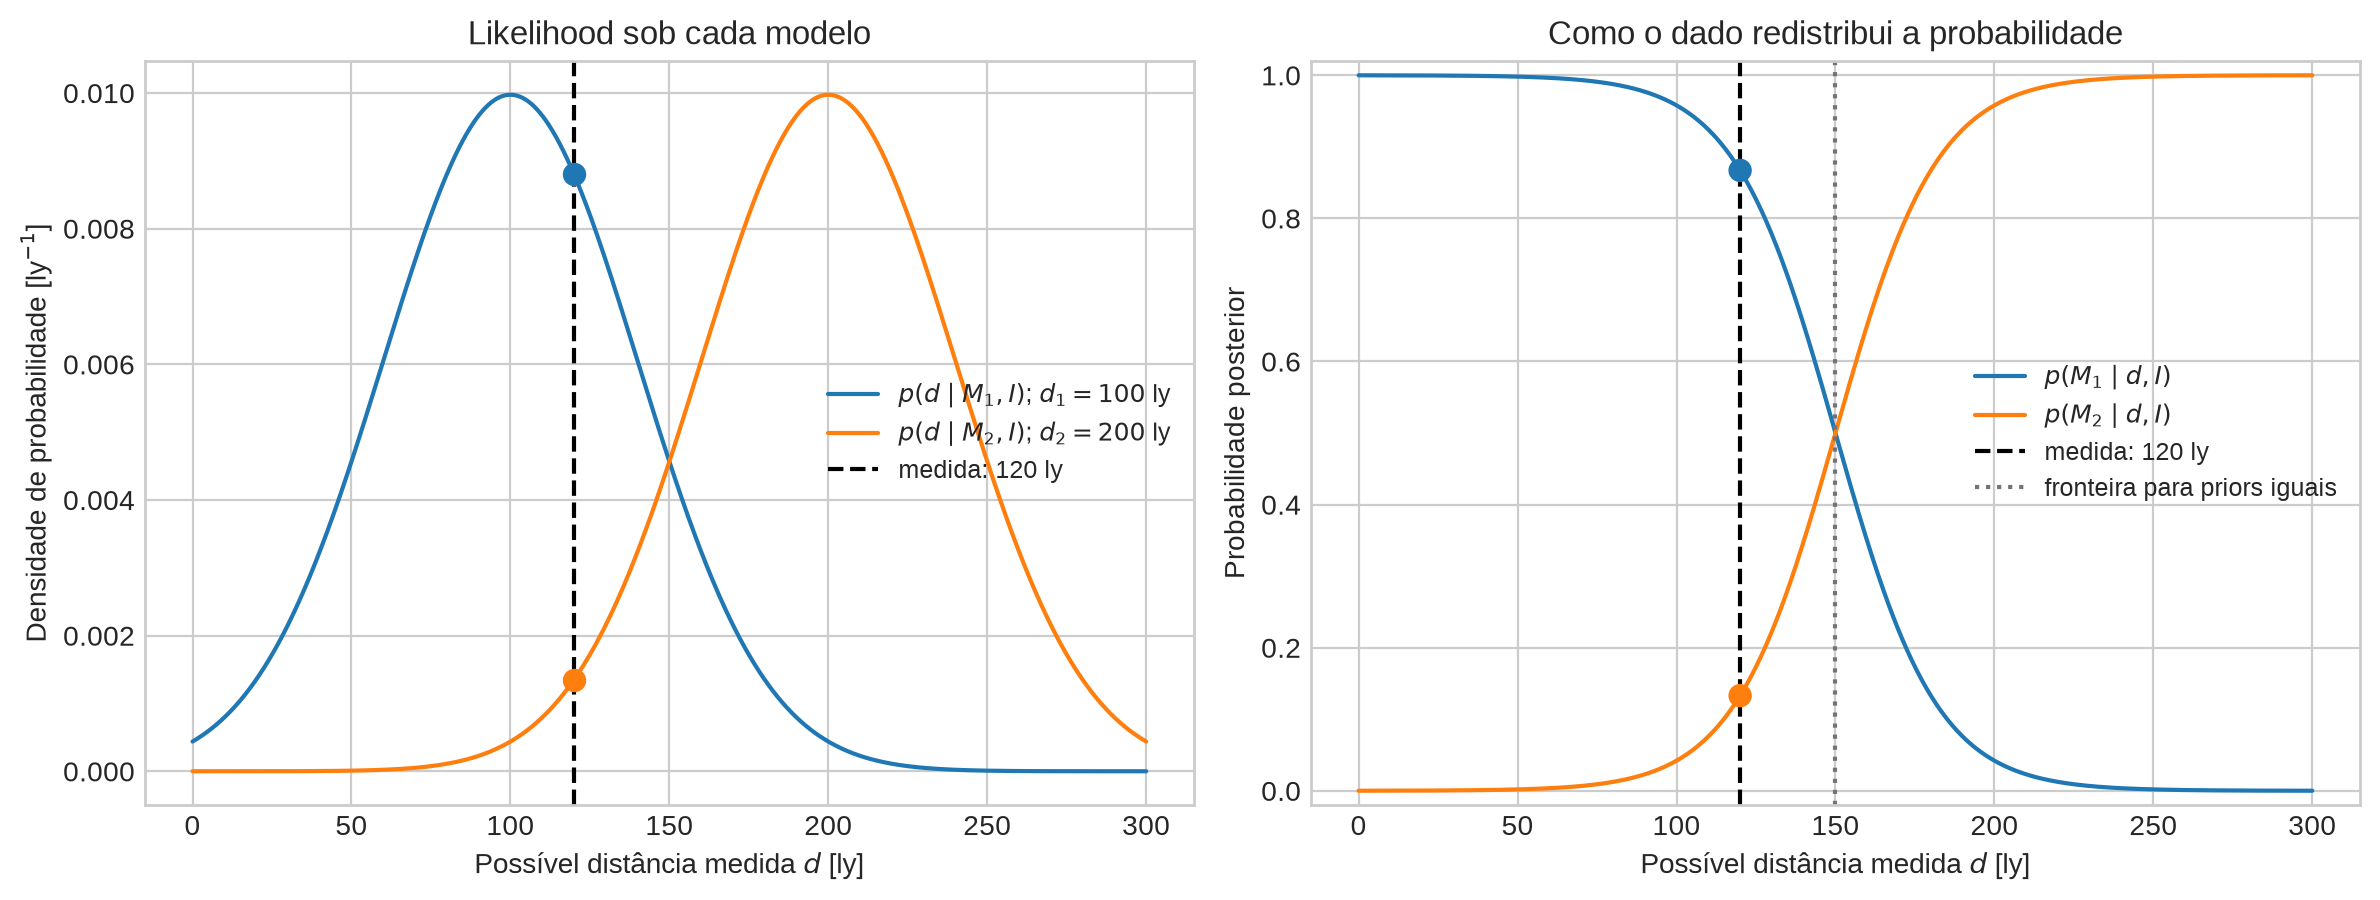

In [4]:
distance_grid = np.linspace(0.0, 300.0, 1000) # Medidas ou possíveis medidas

# Cada linha corresponde a um modelo e cada coluna a um possível dado d.
likelihood_grid = gaussian_pdf(
    distance_grid[None, :],
    predictions[:, None],
    sigma,
) # Matriz para cada linha temos teoria 1 ou 2 e cada coluna todos os possíveis dados. Probabilidade dos dados para determinado modelo


# Posterior de cada modelo para cada possível valor medido.
unnormalized_posterior_grid = priors[:, None] * likelihood_grid
posterior_grid = (
    unnormalized_posterior_grid
    / unnormalized_posterior_grid.sum(axis=0) # Normalizando para cada vetor de dados
)

colors = ("tab:blue", "tab:orange")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for i, (prediction, color) in enumerate(zip(predictions, colors)):
    axes[0].plot(
        distance_grid,
        likelihood_grid[i],
        color=color,
        label=fr"$p(d\mid M_{i + 1},I)$; $d_{i + 1}={prediction:.0f}$ ly",
    )
    axes[0].scatter(measurement, likelihoods[i], color=color, s=55, zorder=3)

axes[0].axvline(
    measurement,
    color="black",
    linestyle="--",
    label="medida: 120 ly",
)
axes[0].set(
    xlabel=r"Possível distância medida $d$ [ly]",
    ylabel=r"Densidade de probabilidade [ly$^{-1}$]",
    title="Likelihood sob cada modelo",
)
axes[0].legend(fontsize=9)

for i, color in enumerate(colors):
    axes[1].plot(
        distance_grid,
        posterior_grid[i],
        color=color,
        label=fr"$p(M_{i + 1}\mid d,I)$",
    )

axes[1].axvline(
    measurement,
    color="black",
    linestyle="--",
    label="medida: 120 ly",
)
axes[1].axvline(
    150.0,
    color="0.45",
    linestyle=":",
    label="fronteira para priors iguais",
)
axes[1].scatter(
    [measurement, measurement],
    posterior,
    color=colors,
    s=55,
    zorder=3,
)
axes[1].set(
    xlabel=r"Possível distância medida $d$ [ly]",
    ylabel="Probabilidade posterior",
    title="Como o dado redistribui a probabilidade",
    ylim=(-0.02, 1.02),
)
axes[1].legend(fontsize=9)

fig.tight_layout()
# fig.savefig("exemplo_1_3_4.png", dpi=300, bbox_inches="tight")
plt.show()

É importante ter em mente que a posterior é uma função de $M_i$ e não dos dados. Estamos apenas vendo como a probabilidade da teoria $M_i$ muda para um possível dado medido. Note que como p(D) muda com D a posterior assume uma forma diferente da gaussiana vista na likelihood.

#### Por que a posterior também não é uma Gaussiana?

Podemos ver que a posterior não será uma gaussiana olhando para a evidência. Como estamos fazendo um gráfico da posterior pelos dados, sendo que a posterior é uma função da teoria, temos que tomar cuidado, pois a normalização varia para cada valor de D que medimos. Um gráfico da evidência ajuda a entender melhor esse resultado e se encontra abaixo. 

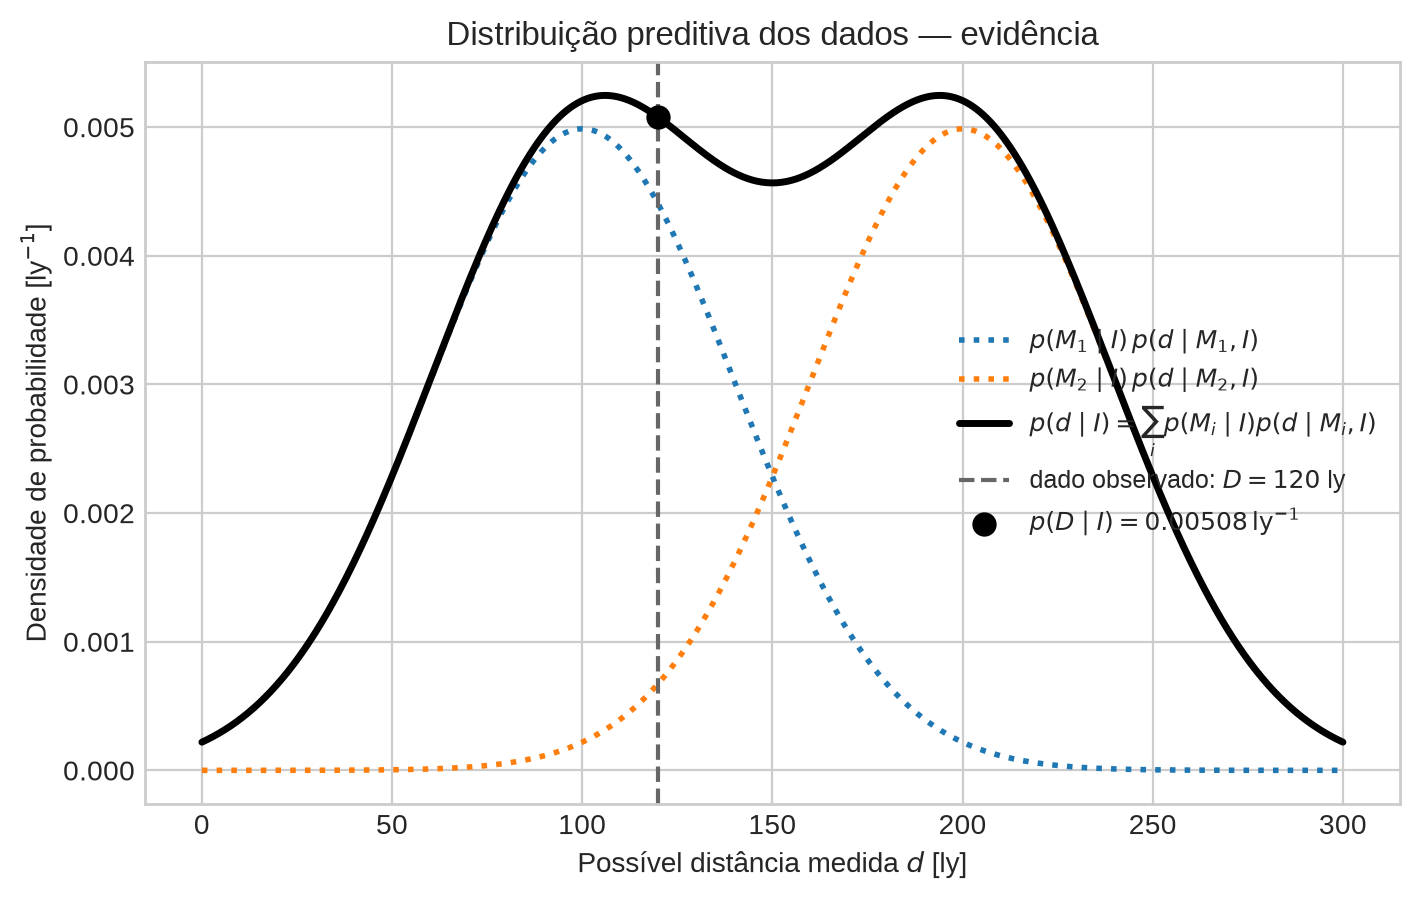

In [5]:
# Contribuição de cada modelo para a distribuição preditiva dos dados
weighted_likelihood_grid = priors[:, None] * likelihood_grid

# Evidência como função de um possível dado d
evidence_grid = weighted_likelihood_grid.sum(axis=0)

fig, ax = plt.subplots(figsize=(7.2, 4.6))

for i, color in enumerate(colors):
    ax.plot(
        distance_grid,
        weighted_likelihood_grid[i],
        color=color,
        linestyle=":",
        linewidth=2,
        label=fr"$p(M_{i+1}\mid I)\,p(d\mid M_{i+1},I)$",
    )

ax.plot(
    distance_grid,
    evidence_grid,
    color="black",
    linewidth=2.5,
    label=r"$p(d\mid I)=\sum_i p(M_i\mid I)p(d\mid M_i,I)$",
)

ax.axvline(
    measurement,
    color="0.4",
    linestyle="--",
    label=fr"dado observado: $D={measurement:.0f}$ ly",
)

ax.scatter(
    measurement,
    evidence,
    color="black",
    s=60,
    zorder=3,
    label=fr"$p(D\mid I)={evidence:.5f}\,\mathrm{{ly}}^{{-1}}$",
)

ax.set(
    xlabel=r"Possível distância medida $d$ [ly]",
    ylabel=r"Densidade de probabilidade [ly$^{-1}$]",
    title="Distribuição preditiva dos dados — evidência",
)

ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

In [6]:
# Aumentar incerteza aumenta compatibilidade entre as teorias (claro) - Testando

# Incerteza muito alta faz o fator de bayes ir para 1, não diz nada sobre nenhuma teoria.

sigma_values = np.array([20.0, 40.0, 80.0, 160.0, 500])

print(" sigma [ly]    p(M1 | D,I)    B12")
print("-----------------------------------")

for sigma_test in sigma_values:
    likelihood_test = gaussian_pdf(measurement, predictions, sigma_test)
    posterior_test, _ = posterior_discrete(priors, likelihood_test)
    bayes_factor_test = likelihood_test[0] / likelihood_test[1]

    print(
        f" {sigma_test:8.1f}      {posterior_test[0]:10.4%}    "
        f"{bayes_factor_test:7.4f}"
    )

 sigma [ly]    p(M1 | D,I)    B12
-----------------------------------
     20.0        99.9447%    1808.0424
     40.0        86.7036%     6.5208
     80.0        61.5088%     1.5980
    160.0        52.9263%     1.1243
    500.0        50.3000%     1.0121


## Exemplo 1.4.1 — frequência como informação

Consideramos uma doença rara com prevalência $p(H\mid I)=10^{-4}$, onde $H$ representa ter a doeça. O teste tem sensiblidade (probabiliade de medir positivo dado que você tem a doença) de $p(+\mid H,I)=0.986$, ou seja, a taxa de falso negativo é **FNR**=$1.4\%$ e taxa de falso positivo **FPR**=$p(+\mid \bar H,I)=0.023$. Após um resultado positivo,

$$
p(H\mid +,I)=
\frac{p(H\mid I)p(+\mid H,I)}
{p(H\mid I)p(+\mid H,I)+p(\bar H\mid I)p(+\mid \bar H,I)}.
$$

A frequência observada da doença entra como a prior — a taxa-base. O denominador é a evidência, que irá utilizar dessa taxa base e vai medir no fundo a probabilidade do dado positivo - Você pode ter a doença e medir positivo ou não ter a doença e também medir positivo.

In [7]:
prevalence = 1e-4
sensitivity = 0.986 # 1-Falso negativo
false_positive_rate = 0.023 # Medir positivo não tendo a doença
improved_false_positive_rate = 0.005 # Pede para utilizar depois e ver como os dados mudam

def posterior_given_positive(prevalence, sensitivity, false_positive_rate):
    "Calcula P(H | +, I) para o teste realizado."
    prevalence = np.asarray(prevalence, dtype=float)
    
    true_positive_probability = prevalence * sensitivity # "Likelihood vezes a prior - Probabilidade de medir positivo dado positivo
    positive_probability = (
        true_positive_probability
        + (1.0 - prevalence) * false_positive_rate
    ) # Probabilidade de você medir positivo - Evidência. Note que a prevalência da doença faz total diferença aqui

    return true_positive_probability / positive_probability # Posterior final

posterior_original = posterior_given_positive(
    prevalence, sensitivity, false_positive_rate
).item()
posterior_improved = posterior_given_positive(
    prevalence, sensitivity, improved_false_positive_rate
).item()

print(f'Com 2,3% de falsos positivos: p(H | +, I) = {posterior_original:.4%}')
print(f'Com 0,5% de falsos positivos: p(H | +, I) = {posterior_improved:.4%}')
print(f'Razão entre as duas posteriores: {posterior_improved / posterior_original:.2f}')

Com 2,3% de falsos positivos: p(H | +, I) = 0.4269%
Com 0,5% de falsos positivos: p(H | +, I) = 1.9341%
Razão entre as duas posteriores: 4.53


Note que a probabiliade de ter a doença com um teste positivo é muito pequena, ainda que a sensibilidade do teste seja extremamente alto. O valor baixo dessa probalidade acontece devido ao baixo valor de prevalência, ou seja, pessoas que de fato possuem a doença. A prevalência faz com que a taxa de falso positivo pese muito. Haverão muitos casos nos quais pessoas não tem doença e medem positivo. 

Como a doença é muito rara, o pequeno percentual de falsos positivos atua
sobre uma população saudável muito maior. Por isso os falsos positivos
dominam o conjunto de resultados positivos.

Exemplo numérico abaixo para entender melhor.

In [8]:
population = 100_000

diseased = population * prevalence
healthy = population * (1.0 - prevalence)
true_positives = diseased * sensitivity
false_positives = healthy * false_positive_rate
total_positives = true_positives + false_positives

print(f"População total:               {population:10,d}")
print(f"Pessoas com a doença:          {diseased:10.2f}")
print(f"Pessoas sem a doença:          {healthy:10.2f}")
print(f"Verdadeiros positivos:         {true_positives:10.2f}")
print(f"Falsos positivos:              {false_positives:10.2f}")
print(f"Total de resultados positivos: {total_positives:10.2f}")
print(
    "\nFração dos positivos que realmente têm a doença: "
    f"{true_positives / total_positives:.4%}")

População total:                  100,000
Pessoas com a doença:               10.00
Pessoas sem a doença:            99990.00
Verdadeiros positivos:               9.86
Falsos positivos:                 2299.77
Total de resultados positivos:    2309.63

Fração dos positivos que realmente têm a doença: 0.4269%


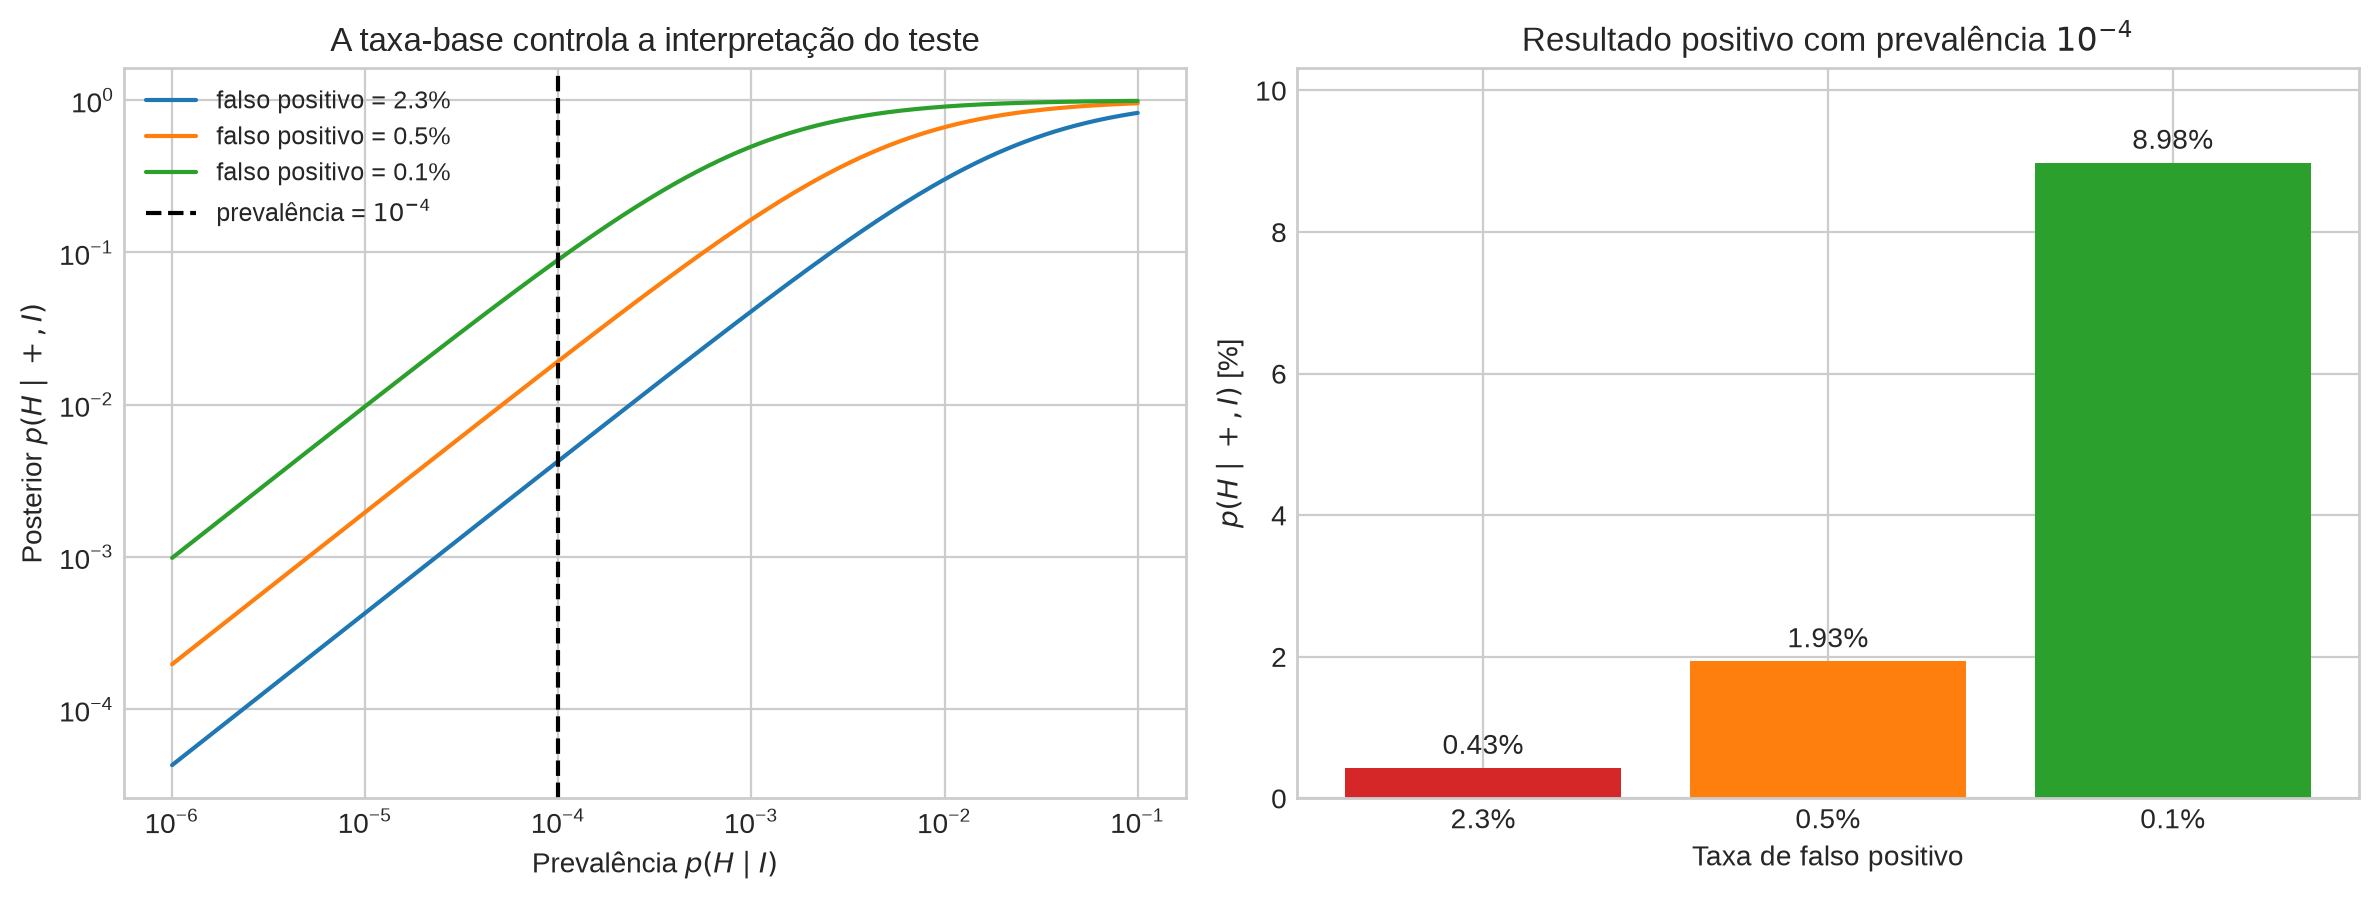

In [9]:
prevalence_grid = np.logspace(-6, -1, 600)
false_positive_rates = np.array([0.023, 0.005, 0.001])

posterior_at_base_rate = np.array(
    [
        posterior_given_positive(prevalence, sensitivity, rate).item()
        for rate in false_positive_rates
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for rate in false_positive_rates:
    curve = posterior_given_positive(prevalence_grid, sensitivity, rate)
    axes[0].plot(
        prevalence_grid,
        curve,
        label=f"falso positivo = {rate:.1%}",
    )

axes[0].axvline(
    prevalence,
    color="black",
    linestyle="--",
    label=r"prevalência = $10^{-4}$",
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set(
    xlabel=r"Prevalência $p(H\mid I)$",
    ylabel=r"Posterior $p(H\mid +,I)$",
    title="A taxa-base controla a interpretação do teste",
)
axes[0].legend(fontsize=9)

bars = axes[1].bar(
    [f"{rate:.1%}" for rate in false_positive_rates],
    100.0 * posterior_at_base_rate,
    color=("tab:red", "tab:orange", "tab:green"),
)
axes[1].bar_label(bars, fmt="%.2f%%", padding=3)
axes[1].set(
    xlabel="Taxa de falso positivo",
    ylabel=r"$p(H\mid +,I)$ [%]",
    title=r"Resultado positivo com prevalência $10^{-4}$",
)
axes[1].set_ylim(0, 1.15 * (100.0 * posterior_at_base_rate).max())

fig.tight_layout()
# fig.savefig("exemplo_1_4_1.png", dpi=300, bbox_inches="tight")
plt.show()

**Quão pequena deve ser a taxa de falso positivo para obter certa posterior**

Podemos inverter a equação para descobrir qual taxa de falso positivo $f$
produz uma posterior-alvo $q$:

$$
q=\frac{\pi s}{\pi s+(1-\pi)f}
\quad\Longrightarrow\quad
f=\frac{\pi s(1-q)}{q(1-\pi)},
$$

onde $\pi$ é a prevalência e $s$ é a sensibilidade.

In [10]:
target_posterior = 0.50

required_false_positive_rate = (
    prevalence
    * sensitivity
    * (1.0 - target_posterior)
    / (target_posterior * (1.0 - prevalence))
)

check_target = posterior_given_positive(
    prevalence,
    sensitivity,
    required_false_positive_rate,
).item()

print(
    "Taxa de falso positivo necessária para uma posterior de 50%: "
    f"{required_false_positive_rate:.8f} "
    f"({required_false_positive_rate:.5%})"
)
print(f"Verificação: p(H | +,I) = {check_target:.4%}")

Taxa de falso positivo necessária para uma posterior de 50%: 0.00009861 (0.00986%)
Verificação: p(H | +,I) = 50.0000%


## Resumo

Para hipóteses discretas e mutuamente exclusivas,

$$
p(H_i\mid D,I)=
\frac{p(H_i\mid I)p(D\mid H_i,I)}
{\sum_j p(H_j\mid I)p(D\mid H_j,I)}.
$$

O denominador é a evidência $p(D\mid I)$. Ele normaliza a posterior e
representa quão provável era observar o dado sob todo o espaço de hipóteses
considerado. 

- no exemplo 1.3.4, o dado modifica as probabilidades relativas dos modelos;
- no exemplo 1.4.1, a prior — a taxa-base — modifica totalmente os resultados da posterior que esperamos intuitivamente